In [217]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import emcee
import corner

dataFromRatraNew = np.array([
        [0.070, 69.,19.6],
        [0.090,69.,12.],
        [0.120,68.6,26.2],
        [0.170,83.,8.],
        [0.179,75.,4.],
        [0.199,75.,5.],
        [0.200,72.9,29.6],
        [0.270,77.0,14.],
        [0.280,88.8,36.6],
        [0.352,83.,14.],
        [0.3802,83.,13.5],
        [0.400,95.,17.],
        [0.4004,77.,10.2],
        [0.4247,87.1,11.2],
        # [0.440,82.6,7.8], #The last paper of Yu ratra et al 2017, arXiv:1711.03437v1
        #discard this measurement.
        [0.4497,92.8,12.9],
        [0.47, 89.0, 50.0],
        #Here the [0.47, 89.0, 50.0] measurement is added to the list.
        [0.4783,80.9,9.],
        [0.480,97.,62.],
        [0.593,104.,13.],
        # [0.600,87.9,6.1], ###??? it is not in the list YuRattra
        [0.680,92.,8.],
        # [0.730,97.3,2.1], ###??? it is not in the list
        [0.781,105.,12.],
        [0.875,125.,17.],
        [0.880,90.,40.],
        [0.900,117.,23.],
        [1.037,154.,20.],
        [1.300,168.0,17.],
        [1.363,160.,33.6],
        [1.430,177.,18.],
        [1.530,140.,14.],
        [1.750,202.,40.],
        [1.965,186.5,50.4] ])

## Method overview

We fit a flat ΛCDM model, H(z) = H0·sqrt(Ωm(1+z)³ + (1−Ωm)), to 30 cosmic chronometer H(z) measurements (dataFromRatraNew), using χ² minimization. Spatial (3D) flatness (Ωm + ΩΛ = 1) is assumed, so only Ωm and H0 are free parameters.

In [218]:
#Takes redsdift(z) and a vector of parameters
def lCDM(z,fpars):
  
  Om_m0 = fpars[0]
  H_0 = fpars[1]
  E = (Om_m0*(1+z)**3 + 1-Om_m0)**0.5
  return E*H_0

In [233]:
# Chi-squared for the minimiser (takes a single array of params)
def chisq(pars):
    sum_chisq = 0
    for dpoint in dataFromRatraNew:
        z = dpoint[0]
        H_obs = dpoint[1]
        sigma = dpoint[2]
        theorH = lCDM(z, pars)
        sum_chisq += (H_obs - theorH)**2 / sigma**2
    return sum_chisq

# Chi-squared for the grid (takes two separate arrays for vectorised plotting)
def chisq_grid(Om_m0, H_0):
    sum_chisq = 0
    for dpoint in dataFromRatraNew:
        z = dpoint[0]
        H_obs = dpoint[1]
        sigma = dpoint[2]
        E = (Om_m0 * (1 + z)**3 + 1 - Om_m0)**0.5
        theorH = E * H_0
        sum_chisq += (H_obs - theorH)**2 / sigma**2
    return sum_chisq

# Minimisation 
x0 = np.array([0.3, 70.0])
bounds = [(0.0, 1.0), (50.0, 100.0)]  # Om_m0 between 0-1, H0 between 50-100
result = opt.minimize(chisq, x0, method='L-BFGS-B', bounds=bounds)
print(result)

pars = [1.00, 72.0]
print(f"x^2[{pars[0]},{pars[1]}]:= {chisq(pars)}\n")

best_pars = result.x
print(f"x^2[{round(best_pars[0],3)},{round(best_pars[1],3)}]:= {chisq(best_pars)}")

Om_m0_best = best_pars[0]
H0_best = best_pars[1]
Om_Lambda_best = 1 - Om_m0_best

print(f"Omega_m     = {round(Om_m0_best, 4)}")
print(f"Omega_Lambda = {round(Om_Lambda_best, 4)}")
print(f"H_0          = {round(H0_best, 4)}")

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 14.499985774271918
        x: [ 3.196e-01  6.815e+01]
      nit: 14
      jac: [-3.553e-07  1.776e-07]
     nfev: 51
     njev: 17
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
x^2[1.0,72.0]:= 457.16367129828075

x^2[0.32,68.15]:= 14.499985774271918
Omega_m     = 0.3196
Omega_Lambda = 0.6804
H_0          = 68.1499


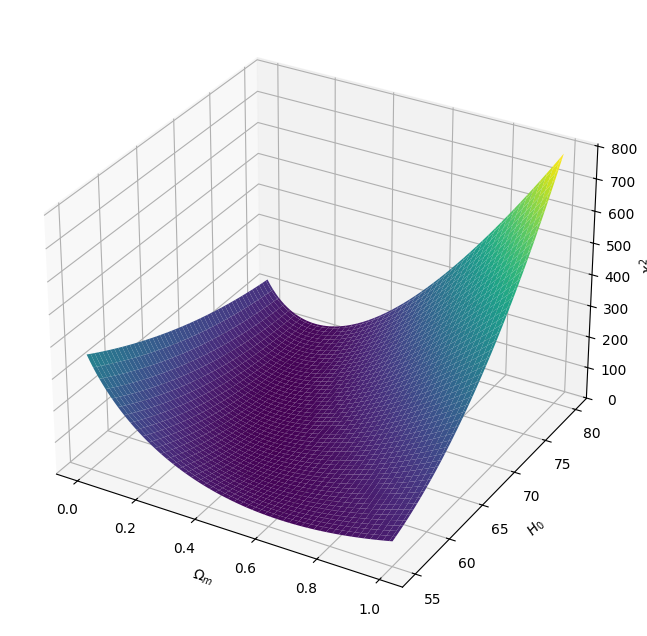

In [234]:
sample_rate = 100

Om_space = np.linspace(0, 1, sample_rate)
H0_space = np.linspace(55, 80, sample_rate)

xx, yy = np.meshgrid(Om_space, H0_space)

Xgrid = np.vstack([xx.ravel(), yy.ravel()]).T

result = chisq([Xgrid[:,0], Xgrid[:,1]])

Z = result.reshape(xx.shape)

fig = plt.figure(figsize=(13,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, Z, cmap='viridis')

ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel(r'$H_0$')
ax.set_zlabel(r'$\chi^2$')

plt.show()

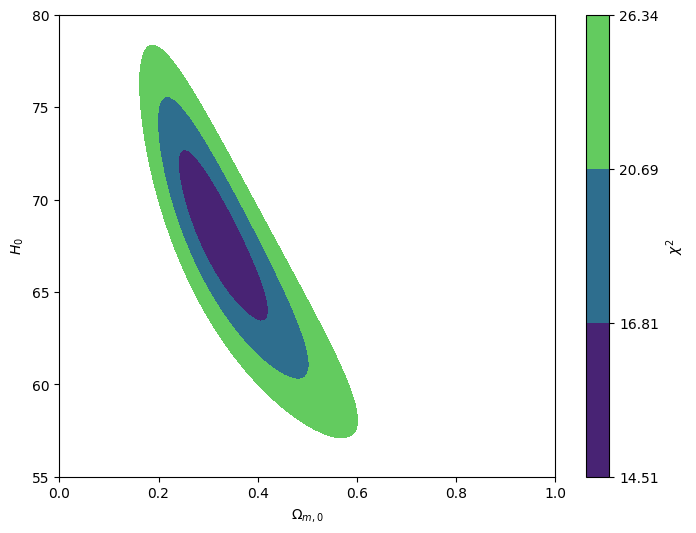

In [235]:
fig, ax = plt.subplots(figsize=(8,6))

chi2_min = Z.min()
# Δχ² for 2 parameters: 68%, 95%, 99% confidence
levels = chi2_min + np.array([0, 2.30, 6.18, 11.83])

cf = ax.contourf(xx, yy, Z, levels=levels, cmap='viridis')

ax.set_xlabel(r'$\Omega_{m,0}$')
ax.set_ylabel(r'$H_0$')

fig.colorbar(cf, ax=ax, label=r'$\chi^2$')

plt.show()

## Confidence regions

The χ² grid is scanned around the best fit and used to draw 68%/95%/99% confidence contours (Δχ² = 2.30, 6.18, 11.83 for 2 free parameters). This shows the Ωm–H0 degeneracy directly, which a single ± error bar on each parameter can't fully capture.

In [236]:
# new code to extract best-fit parameters and their uncertainties
def H_model(z, Om_m0, H0):
    return H0 * np.sqrt(Om_m0 * (1 + z)**3 + (1 - Om_m0))

z_data     = dataFromRatraNew[:, 0]
H_data     = dataFromRatraNew[:, 1]
sigma_data = dataFromRatraNew[:, 2]

p0 = [0.3, 70.0]
bounds = ([0.0, 40.0], [1.0, 100.0])

popt, pcov = opt.curve_fit(
    H_model, z_data, H_data,
    p0=p0, sigma=sigma_data, absolute_sigma=True, bounds=bounds
)

Omega_m, H_0 = popt
Omega_m_err, H_0_err = np.sqrt(np.diag(pcov))
Omega_Lambda = 1 - Omega_m
Omega_Lambda_err = Omega_m_err   # same error, since Omega_Lambda = 1 - Omega_m

chi2_min = np.sum((H_data - H_model(z_data, *popt))**2 / sigma_data**2)
dof = len(z_data) - len(popt)

print(f"Omega_m       = {Omega_m:.4f} ± {Omega_m_err:.4f}")
print(f"Omega_Lambda  = {Omega_Lambda:.4f} ± {Omega_Lambda_err:.4f}")
print(f"H_0           = {H_0:.4f} ± {H_0_err:.4f}")
print(f"chi^2_reduced = {chi2_min:.2f}/{dof} = {chi2_min/dof:.3f}")

Omega_m       = 0.3196 ± 0.0593
Omega_Lambda  = 0.6804 ± 0.0593
H_0           = 68.1499 ± 3.0781
chi^2_reduced = 14.50/29 = 0.500


## Best fit & uncertainties

`curve_fit` minimizes the same χ² as a manual `minimize` call, but also returns the parameter covariance matrix (computed from the fit residuals and the measurement errors, since `absolute_sigma=True`). This gives proper 1σ uncertainties on Ωm and H0, rather than just a single point estimate. χ²/dof ≈ 1 indicates the model fits the data well given the quoted measurement errors.

## MCMC (Markov Chain Monte Carlo) cross-check

`curve_fit`'s uncertainties assume the posterior is Gaussian (a local quadratic approximation around the minimum). We use `emcee` to sample the actual posterior distribution via MCMC, as a check on that assumption — if the MCMC and curve_fit uncertainties agree closely, the Gaussian approximation was adequate here.

In [237]:
#  MCM sampling of the posterior on (Omega_m, H0) 

def log_prior(theta):
    Om_m0, H0 = theta
    if 0.0 < Om_m0 < 1.0 and 40.0 < H0 < 100.0:
        return 0.0
    return -np.inf

def log_likelihood(theta):
    Om_m0, H0 = theta
    model = H_model(z_data, Om_m0, H0)
    return -0.5 * np.sum((H_data - model)**2 / sigma_data**2)

def log_prob(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

ndim, nwalkers, nsteps = 2, 32, 3000

# start walkers as a small Gaussian ball around the curve_fit best fit
pos = popt + 1e-3 * np.random.randn(nwalkers, ndim) * np.array([1, 10])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(pos, nsteps, progress=False)

# discard burn-in (first 500 steps) and thin by 15 to reduce autocorrelation
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

Om_mcmc = np.percentile(flat_samples[:, 0], [16, 50, 84])
H0_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])

# derived parameter: Omega_Lambda = 1 - Omega_m (flatness), from the same chain
Om_Lambda_samples = 1 - flat_samples[:, 0]
OL_mcmc = np.percentile(Om_Lambda_samples, [16, 50, 84])

print(f"Omega_m      = {Om_mcmc[1]:.4f} (+{Om_mcmc[2]-Om_mcmc[1]:.4f} / -{Om_mcmc[1]-Om_mcmc[0]:.4f})")
print(f"Omega_Lambda = {OL_mcmc[1]:.4f} (+{OL_mcmc[2]-OL_mcmc[1]:.4f} / -{OL_mcmc[1]-OL_mcmc[0]:.4f})")
print(f"H_0          = {H0_mcmc[1]:.2f} (+{H0_mcmc[2]-H0_mcmc[1]:.2f} / -{H0_mcmc[1]-H0_mcmc[0]:.2f})")

Omega_m      = 0.3297 (+0.0664 / -0.0567)
Omega_Lambda = 0.6703 (+0.0567 / -0.0664)
H_0          = 67.58 (+3.14 / -3.05)


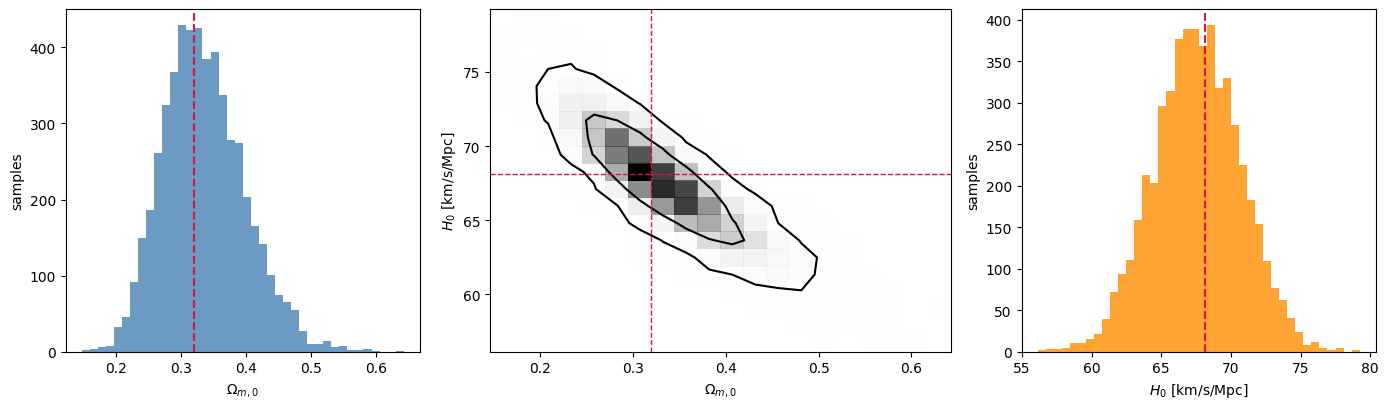

In [238]:
# Posterior summary, horizontal layout (marginal | joint contour | marginal) 

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={'width_ratios': [1, 1.3, 1]})

# left panel: Omega_m marginal distribution
axes[0].hist(flat_samples[:, 0], bins=40, color='steelblue', alpha=0.8)
axes[0].axvline(Omega_m, color='crimson', linestyle='--')
axes[0].set_xlabel(r"$\Omega_{m,0}$")
axes[0].set_ylabel("samples")

# middle panel: joint 2D posterior with 68%/95% contours
corner.hist2d(flat_samples[:, 0], flat_samples[:, 1], ax=axes[1],
              levels=(0.68, 0.95), plot_datapoints=False)
axes[1].axvline(Omega_m, color='crimson', linestyle='--', linewidth=1)
axes[1].axhline(H_0, color='crimson', linestyle='--', linewidth=1)
axes[1].set_xlabel(r"$\Omega_{m,0}$")
axes[1].set_ylabel(r"$H_0$ [km/s/Mpc]")

# right panel: H0 marginal distribution
axes[2].hist(flat_samples[:, 1], bins=40, color='darkorange', alpha=0.8)
axes[2].axvline(H_0, color='crimson', linestyle='--')
axes[2].set_xlabel(r"$H_0$ [km/s/Mpc]")
axes[2].set_ylabel("samples")

plt.tight_layout()
plt.show()

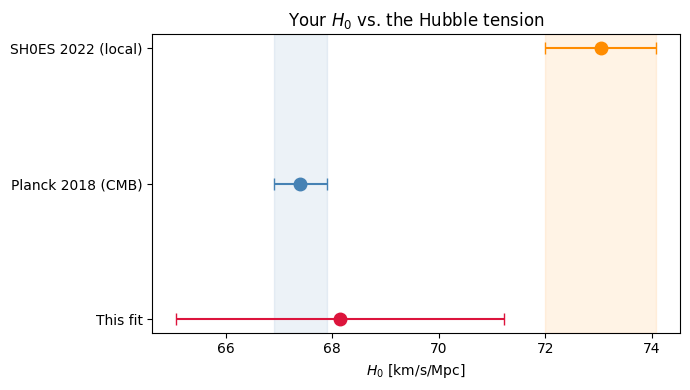

In [239]:
# H0 tension comparison: your result vs. the two landmark measurements 

literature = {
    "This fit":     (H_0, H_0_err,   'crimson'),
    "Planck 2018 (CMB)":   (67.4,  0.5,  'steelblue'),
    "SH0ES 2022 (local)":  (73.04, 1.04, 'darkorange'),
}

fig, ax = plt.subplots(figsize=(7, 4))
for i, (label, (val, err, color)) in enumerate(literature.items()):
    ax.errorbar(val, i, xerr=err, fmt='o', color=color, capsize=4, markersize=9)

ax.set_yticks(range(len(literature)))
ax.set_yticklabels(literature.keys())
ax.set_xlabel(r"$H_0$ [km/s/Mpc]")
ax.set_title("Your $H_0$ vs. the Hubble tension")
ax.axvspan(67.4-0.5, 67.4+0.5, color='steelblue', alpha=0.1)
ax.axvspan(73.04-1.04, 73.04+1.04, color='darkorange', alpha=0.1)
plt.tight_layout()
plt.show()

## Context: the Hubble tension

Our fitted H0 is compared against two landmark measurements: Planck 2018 (CMB, early-universe) and SH0ES 2022 (local distance ladder, late-universe). Seeing where this H(z)-based fit lands relative to both gives useful context for how consistent (or not) this dataset is with either camp.

N.B.: These two methods disagree at >4σ — the "Hubble tension" — one of the open problems in current cosmology. 